In [1]:
import numpy as np
from scipy.signal import firwin, filtfilt
import matplotlib.pyplot as plt

In [2]:
def bandpass_filter(
    sig,
    fs,
    lowcut,
    highcut,
    numtaps=101,
    window="hamming",
):
    """
    Apply a FIR bandpass filter to a 1D signal.

    Parameters
    ----------
    sig : array_like
        Input signal (1D NumPy array).
    fs : float
        Sampling frequency in Hz.
    lowcut : float
        Low cutoff frequency in Hz.
    highcut : float
        High cutoff frequency in Hz.
    numtaps : int, optional
        Length of the FIR filter (order+1). Larger = sharper filter, more delay.
    window : str, optional
        Window type for firwin.

    Returns
    -------
    filtered_sig : ndarray
        Bandpass-filtered signal (same shape as input).
    """
    # Normalize cutoffs to Nyquist
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    # Design FIR bandpass filter
    taps = firwin(
        numtaps,
        [low, high],
        pass_zero=False,
        window=window,
    )

    # Zero-phase filtering to avoid phase distortion
    filtered_sig = filtfilt(taps, [1.0], sig)

    return filtered_sig

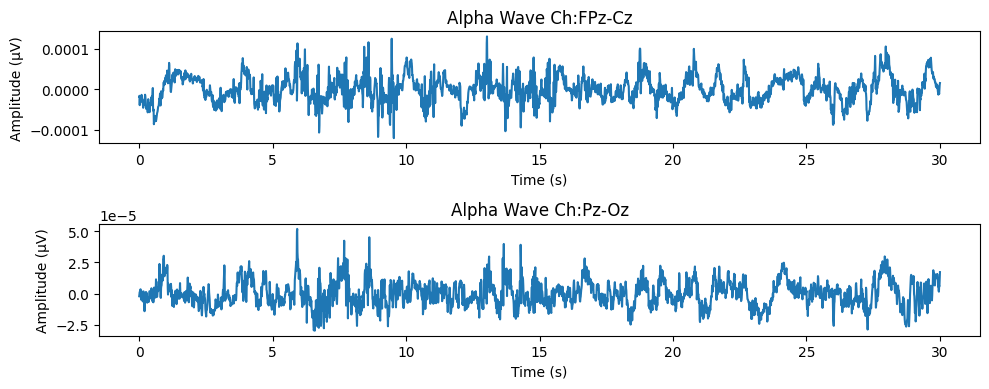

In [3]:
sig = np.load('alpha_waves_data.npy')
fs = 100
t = np.arange(sig.shape[1]) / fs

plt.figure(figsize=(10, 4))
plt.subplot(2,1,1)
plt.plot(t, sig[0])
plt.title('Alpha Wave Ch:FPz-Cz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.subplot(2,1,2)
plt.plot(t, sig[1])
plt.title('Alpha Wave Ch:Pz-Oz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.tight_layout()
plt.show()  

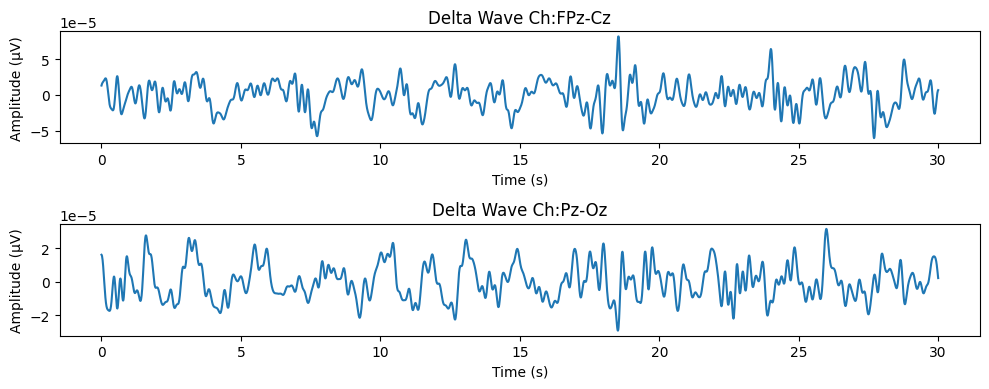

In [4]:
sig = np.load('delta_waves_data.npy')
fs = 100
t = np.arange(sig.shape[1]) / fs

plt.figure(figsize=(10, 4))
plt.subplot(2,1,1)
plt.plot(t, sig[0])
plt.title('Delta Wave Ch:FPz-Cz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.subplot(2,1,2)
plt.plot(t, sig[1])
plt.title('Delta Wave Ch:Pz-Oz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.tight_layout()
plt.show() 

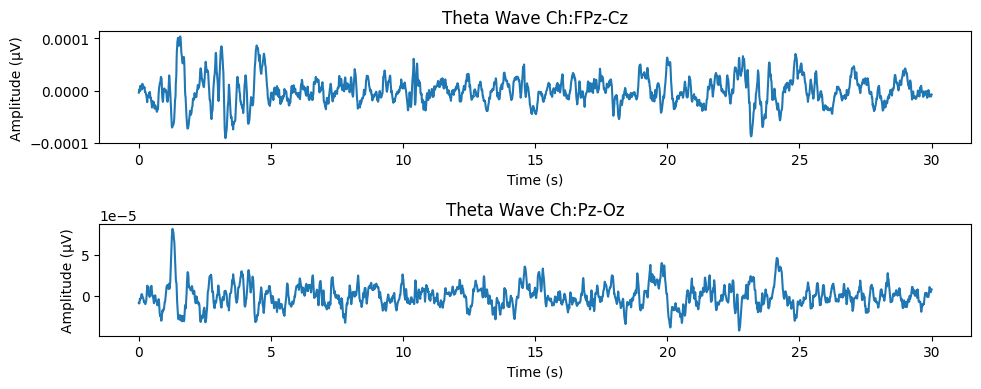

In [5]:
sig = np.load('theta_waves_data.npy')
fs = 100
t = np.arange(sig.shape[1]) / fs

plt.figure(figsize=(10, 4))
plt.subplot(2,1,1)
plt.plot(t, sig[0])
plt.title('Theta Wave Ch:FPz-Cz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.subplot(2,1,2)
plt.plot(t, sig[1])
plt.title('Theta Wave Ch:Pz-Oz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.tight_layout()
plt.show() 

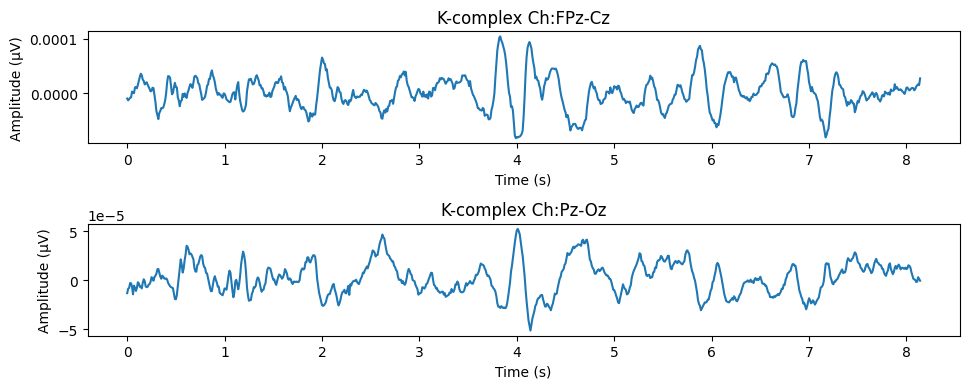

In [6]:
sig = np.load('Kcomplex_data.npy')
fs = 100
t = np.arange(sig.shape[1]) / fs

plt.figure(figsize=(10, 4))
plt.subplot(2,1,1)
plt.plot(t, sig[0])
plt.title('K-complex Ch:FPz-Cz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.subplot(2,1,2)
plt.plot(t, sig[1])
plt.title('K-complex Ch:Pz-Oz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.tight_layout()
plt.show() 

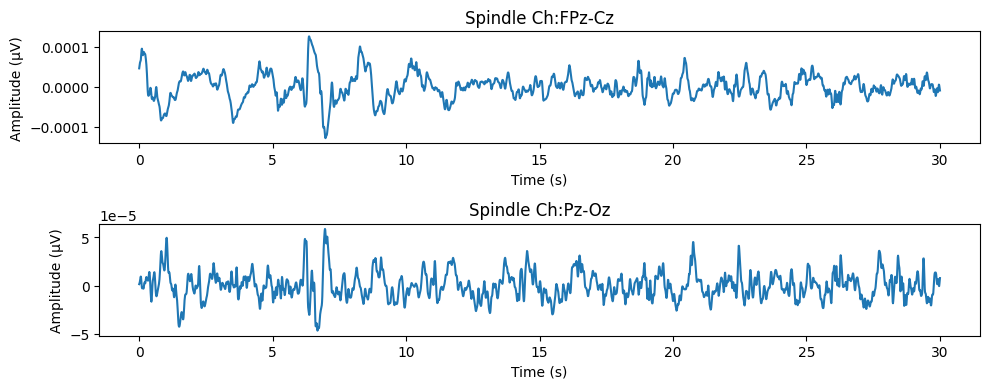

In [7]:
sig = np.load('spindles_data.npy')
fs = 100
t = np.arange(sig.shape[1]) / fs

plt.figure(figsize=(10, 4))
plt.subplot(2,1,1)
plt.plot(t, sig[0])
plt.title('Spindle Ch:FPz-Cz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.subplot(2,1,2)
plt.plot(t, sig[1])
plt.title('Spindle Ch:Pz-Oz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')    
plt.tight_layout()
plt.show() 

## (d) Surrogate realisations and cross-correlation

For each recording: generate phase-randomized surrogate, plot original vs surrogate in time domain, compute and compare cross-correlation between channels.

In [ ]:
# Surrogate: phase randomization per channel (preserves power spectrum)
import glob
np.random.seed(42)
fs = 100

def phase_randomized_surrogate(sig):
    surr = np.zeros_like(sig)
    for ch in range(sig.shape[0]):
        X = np.fft.rfft(sig[ch])
        rnd_phase = np.random.uniform(0, 2 * np.pi, size=X.shape[0])
        surr[ch] = np.fft.irfft(np.abs(X) * np.exp(1j * rnd_phase), n=sig.shape[1])
    return surr

recordings = [
    ('alpha_waves_data.npy', 'Alpha'), ('delta_waves_data.npy', 'Delta'),
    ('theta_waves_data.npy', 'Theta'), ('Kcomplex_data.npy', 'K-complex'), ('spindles_data.npy', 'Spindles'),
]

for fname, label in recordings:
    sig = np.load(fname)
    t = np.arange(sig.shape[1]) / fs
    surr = phase_randomized_surrogate(sig)
    # Time domain: original vs surrogate
    fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
    axes[0,0].plot(t, sig[0], color='C0'); axes[0,0].set_ylabel('Ch0 (µV)'); axes[0,0].set_title(f'{label} – Original Ch0')
    axes[0,1].plot(t, sig[1], color='C1'); axes[0,1].set_ylabel('Ch1 (µV)'); axes[0,1].set_title(f'{label} – Original Ch1')
    axes[1,0].plot(t, surr[0], color='C0', alpha=0.8); axes[1,0].set_ylabel('Ch0 (µV)'); axes[1,0].set_xlabel('Time (s)'); axes[1,0].set_title(f'{label} – Surrogate Ch0')
    axes[1,1].plot(t, surr[1], color='C1', alpha=0.8); axes[1,1].set_ylabel('Ch1 (µV)'); axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_title(f'{label} – Surrogate Ch1')
    plt.suptitle(f'Time domain: Original vs Surrogate — {label}')
    plt.tight_layout(); plt.show()
    # Cross-correlation between channels
    R_orig = np.corrcoef(sig[0], sig[1])[0,1]
    R_surr = np.corrcoef(surr[0], surr[1])[0,1]
    print(f'{label}: cross-corr original = {R_orig:.4f}, surrogate = {R_surr:.4f}')
    # Correlation matrices comparison
    C_orig, C_surr = np.corrcoef(sig), np.corrcoef(surr)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))
    for ax, C, tit in [(ax1, C_orig, 'Original'), (ax2, C_surr, 'Surrogate'), (ax3, C_orig - C_surr, 'Difference')]:
        im = ax.imshow(C, vmin=-1 if tit != 'Difference' else None, vmax=1 if tit != 'Difference' else None, cmap='RdBu_r')
        ax.set_title(f'{label} – {tit}')
        ax.set_xticks([0,1]); ax.set_yticks([0,1]); ax.set_xticklabels(['Ch0','Ch1']); ax.set_yticklabels(['Ch0','Ch1'])
        for i in range(2):
            for j in range(2): ax.text(j, i, f'{C[i,j]:.3f}', ha='center', va='center')
        plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()
print('Done.')